# Multi-class Image Classification

We've just been through a bunch of the folowing steps with a binary classification problem (pizza vs. steak), now we're going to step things up a notch with 10 classes of food

1. Become one with the data
2. Preprocess the data (get ready for a model)
3. Create a model (start with a baseline)
4. Fit the model (overfit it to make sure it works)
5. Evaluate the model
6. Adjust different hyperparameters and improve the model (try to beat baseline)
7. Repeat untill satisfied

### Import and become one with data

In [ ]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2026-05-25 17:38:58--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   120MB/s    in 4.0s    

2026-05-25 17:39:03 (123 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
# Unzip our data
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip", "r")
zip_ref.extractall()
zip_ref.close()

In [ ]:
import os

#Walkthrough 10 classes of food image data
for dirpath, dirnames, filenames in os.walk("10_food_classes_all_data"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/train'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'.
There are 0 directories and 750 images in '10_food_classes_all_data/train/steak'.

In [ ]:
# Setup the traşn and test directories
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [ ]:
# Let's get the class names
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
import random
def view_random_image(target_dir, target_class):
  # Setup the target directory (we'll view images from here)
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)

  #Read in the image and plot it using matpllotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}")

  return img

['2251965.jpg']
Image shape: (512, 512, 3)


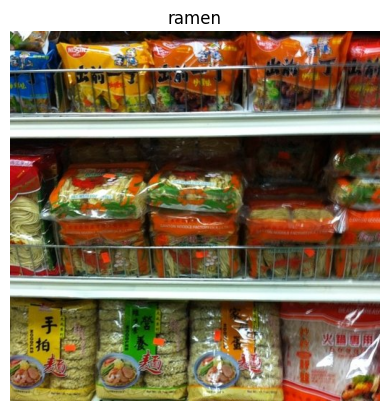

In [ ]:
# Visualize, visualize, visualize
import random
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names))

In [ ]:
random.choice(class_names)

np.str_('chicken_curry')

### 2. Preprocess the data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode="categorical")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode="categorical")

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


### 3. Create a CNN model (start with a baseline)

Link to exercise :  
https://poloclub.github.io/cnn-explainer/#article-convolution

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Activation

In [ ]:
# Create our model
model_1 = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    Conv2D(10, 3),
    Activation("relu"),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation="softmax") # for multi-class
])
# Compile the model
model_1.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])


### 4. Fit the model

In [ ]:
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.1891 - loss: 2.1871 - val_accuracy: 0.2220 - val_loss: 2.1218
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.2873 - loss: 2.0014 - val_accuracy: 0.3076 - val_loss: 1.9719
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.4144 - loss: 1.7099 - val_accuracy: 0.3112 - val_loss: 1.9787
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.6097 - loss: 1.1692 - val_accuracy: 0.2960 - val_loss: 2.2963
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.8089 - loss: 0.5955 - val_accuracy: 0.2768 - val_loss: 3.2464


### 5. Evaluate the model

In [ ]:
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 430ms/step - accuracy: 0.2768 - loss: 3.2464


[3.2464334964752197, 0.2768000066280365]

In [ ]:
# Plot the validation and training curves seperately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot loss
  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label="val_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label="training_accuracy")
  plt.plot(epochs, val_accuracy, label="val_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

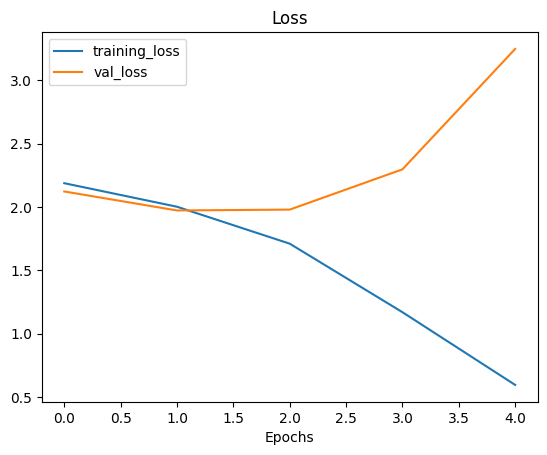

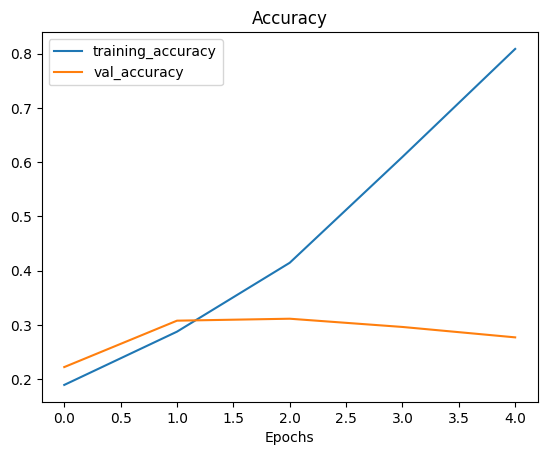

In [ ]:
# Check out the model's loss curves on the 10 classes
plot_loss_curves(history_1)

What do these loss curves tell us?

Well... it seems our model is **overfitting** the training set quite badly... in other words, it's getting great results on the training data but fails to generalize well to unseen data and performs poorly on the test dataset.


### 6. Adjust the model hyperparameters (to beat our baseline model)  

Due to it's performance on the training data, it is clear our model is learning something.

However, it's not generalizing well to unseen data (overfitting).  

So, let's try and fix overfitting by ...  

* ** Get more data**

* ** Simplify the model** - if our current model is overfitting the data, it may be too complicated of a model, one way to simplify a model is to: reduce # of layers or reduce # hiden units in layers.  

* ** Use data augmentation** - manipulates training data in such a way to diversity to it (without altering the original data)  

* ** Use transfor learning** - leverages the patterns another model has learned on similar data to your own and allows you to use those patterns on your own dataset.  



In [ ]:
# How about we try and simplify the model first
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,920 (1.08 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Let's try to remove 2 convolutional layers
model_2 = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation="softmax")
])
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])


In [ ]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,800 (1.12 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit with 2 Conv layers
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 32s 120ms/step - accuracy: 0.2524 - loss: 2.0908 - val_accuracy: 0.3040 - val_loss: 1.9624
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.3984 - loss: 1.7721 - val_accuracy: 0.3608 - val_loss: 1.8251
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.5200 - loss: 1.4697 - val_accuracy: 0.3712 - val_loss: 1.8095
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.6899 - loss: 0.9933 - val_accuracy: 0.3512 - val_loss: 1.9782
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.8461 - loss: 0.5468 - val_accuracy: 0.3260 - val_loss: 2.4078


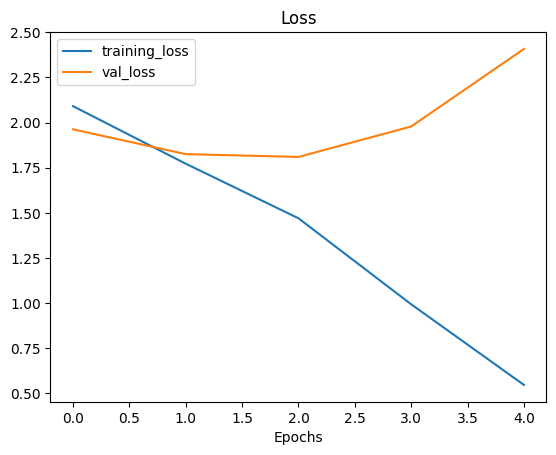

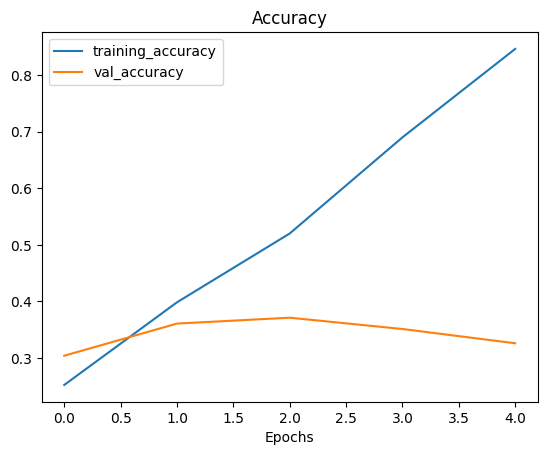

In [ ]:
plot_loss_curves(history_2)

Looks like our simplifying the model experiment didn't work.  
The accuracy went down and overfitting continued.  
How about we try data augmentation??  


### Trying to reduce overfitting with data augmentatiıon  

ıdeally, we want to:  
* Reduce overfitting (get the train and validation loss curves closer)  
* Improve validation acccuracy  

In [ ]:
# Create augmented data generator instance
train_datagen_augmented = ImageDataGenerator(rescale=(1/255.),
                                             rotation_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                  target_size=(224, 224),
                                                                  batch_size=32,
                                                                  class_mode="categorical")

Found 7500 images belonging to 10 classes.


clone_model ->> it creates new layers (and thus new weights) instead of sharing the weights of the existing layers.

In [ ]:
# Let's creaate another model but this time we will fit it on the augmented train data.
model_3 = tf.keras.models.clone_model(model_1)
model_3.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,920 (1.08 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_3 = model_3.fit(train_data_augmented,
                         epochs=5,
                         steps_per_epoch=len(train_data_augmented),
                         validation_data=test_data,
                         validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 110s 445ms/step - accuracy: 0.1913 - loss: 2.1754 - val_accuracy: 0.2992 - val_loss: 1.9820
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 100s 424ms/step - accuracy: 0.3051 - loss: 1.9754 - val_accuracy: 0.3328 - val_loss: 1.9268
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 101s 428ms/step - accuracy: 0.3443 - loss: 1.9036 - val_accuracy: 0.3904 - val_loss: 1.7828
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 105s 445ms/step - accuracy: 0.3664 - loss: 1.8450 - val_accuracy: 0.4076 - val_loss: 1.7471
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 99s 420ms/step - accuracy: 0.3797 - loss: 1.8119 - val_accuracy: 0.4276 - val_loss: 1.6944


In [ ]:
model_3.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.4276 - loss: 1.6944


[1.6944140195846558, 0.4275999963283539]

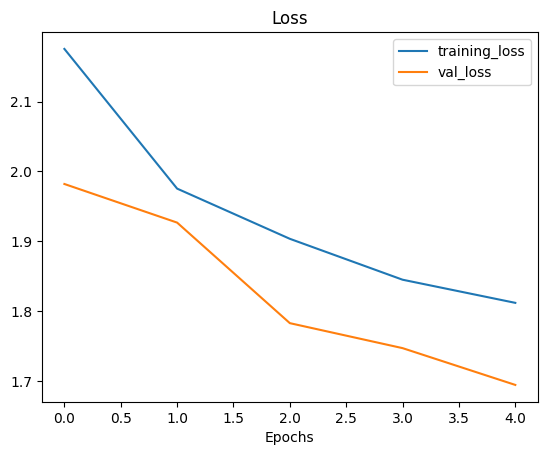

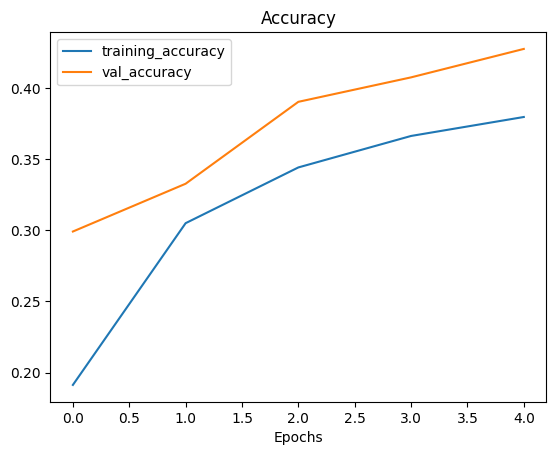

In [ ]:
plot_loss_curves(history_3)

Woaaah! That looks much better, the loss curves are much closer to each other than the baseline model and they look like they're heading in right direction (cretainly not the wrong direction) so if we were to train for longer, we might see further improments.

### 7. Repeat untill satisfied  

How ?

* Restructuring our model's architecture (increasing layers / hidden units)  
* Adjust the learning rate  
* try different methods of data augmentation (adjust the hyperparameters in pur ImageDataGenerator instance)  
* training longer (increase epochs)  
* try **transfer learning**  


### Make a prediction with our trained model

In [ ]:
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [ ]:
# Download some images
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg



--2026-05-25 19:06:12--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1725178 (1.6M) [image/jpeg]
Saving to: ‘03-sushi.jpeg’

03-sushi.jpeg       100%[===================>]   1.64M  --.-KB/s    in 0.04s   

2026-05-25 19:06:13 (44.1 MB/s) - ‘03-sushi.jpeg’ saved [1725178/1725178]

--2026-05-25 19:06:13--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response...

In [ ]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image file and turns it into a tensor with RGB channels (3).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)
  #Decode the read file into a tensor
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img.set_shape([None, None, 3])
  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size=[img_shape, img_shape])
  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
hamburger = load_and_prep_image("03-hamburger.jpeg")
steak = load_and_prep_image("03-steak.jpeg")
sushi = load_and_prep_image("03-sushi.jpeg")

In [ ]:
hamburger.shape

TensorShape([224, 224, 3])

In [ ]:
def pred_and_plot(model, filename, class_names=class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  img = load_and_prep_image(filename)

  pred = model.predict(tf.expand_dims(img, axis=0))

  # Add in logic for multi-class
  if len(pred[0]) > 1:
    pred_class = class_names[pred.argmax()] # if more than one output, take the max
  else:
    pred_class = class_names[int(tf.round(pred)[0][0])]

  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


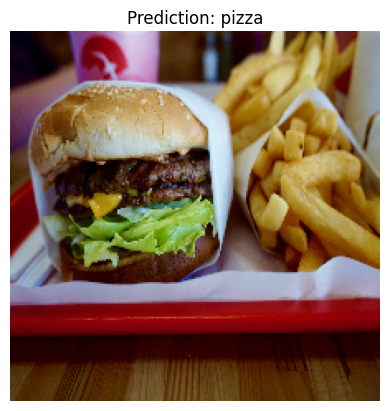

In [ ]:
# Make a prediction using model
pred_and_plot(model=model_3,
              filename="03-hamburger.jpeg",
              class_names=class_names)

Upps :)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


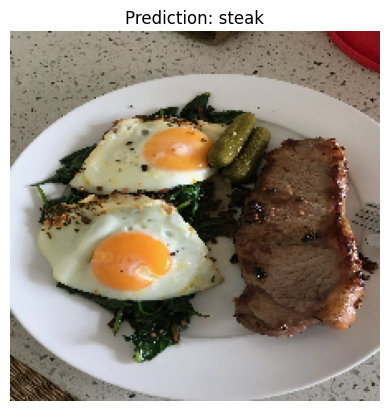

In [ ]:
pred_and_plot(model=model_3,
              filename="03-steak.jpeg",
              class_names=class_names)

yeey :)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


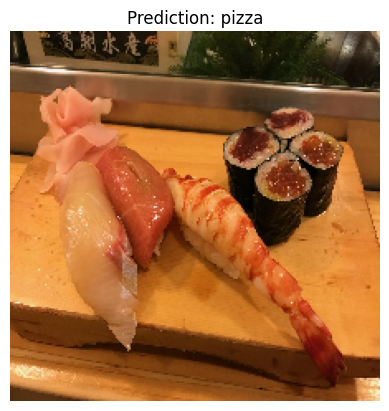

In [ ]:
pred_and_plot(model=model_3,
              filename="03-sushi.jpeg",
              class_names=class_names)

upps again :)

⚓ We need to improve our model ⚓

### Saving and loading our model

In [ ]:
model_3.save("saved_trained_model_3.keras")

In [ ]:
# Load in a trained model evaluated it
loaded_model = tf.keras.models.load_model("saved_trained_model_3.keras")

In [ ]:
loaded_model.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.4276 - loss: 1.6944


[1.694414496421814, 0.4275999963283539]

In [ ]:
model_3.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.4276 - loss: 1.6944


[1.694413661956787, 0.4275999963283539]